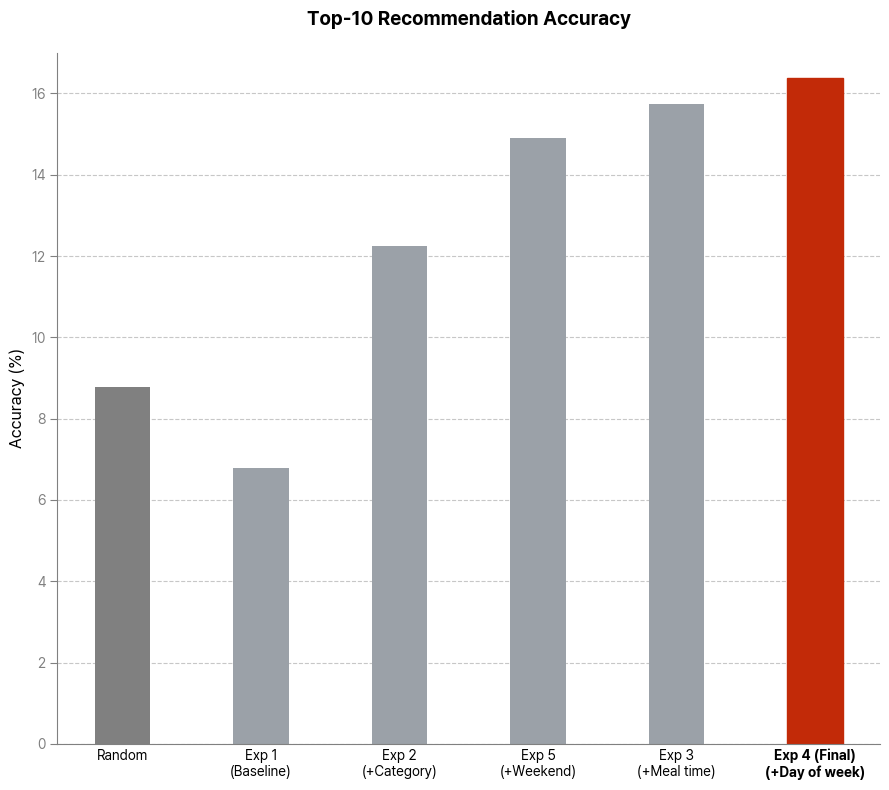

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# 한글 폰트 설정 (MacOS의 AppleGothic 사용)
try:
    plt.rc('font', family='Pretendard')
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지
except:
    print("Pretendard 폰트를 찾을 수 없습니다. 기본 폰트로 그래프를 생성합니다.")

# --- 데이터 정의 (Exp 5 결과 추가) ---
model_accuracies = {
    'Random': 8.77,
    'Exp 1\n(Baseline)': 6.79,
    'Exp 2\n(+Category)': 12.25,
    'Exp 3\n(+Meal time)': 15.73,
    'Exp 4 (Final)\n(+Day of week)': 16.39,
    'Exp 5\n(+Weekend)': 14.90  # Exp 5 데이터 추가
}

# 실험 모델을 성능순으로 정렬
exp_models = {k: v for k, v in model_accuracies.items() if 'Random' not in k}
sorted_exp = sorted(exp_models.items(), key=lambda item: item[1])

# 정렬된 순서에 맞게 라벨과 값 재구성 (오류 수정)
labels_sorted = ['Random'] + [item[0] for item in sorted_exp]
# .replace()를 제거하여 원본 키로 값을 찾도록 수정
accuracies_sorted = [model_accuracies[label] for label in labels_sorted]

# --- 그래프 생성 ---
fig, ax = plt.subplots(figsize=(9, 8))
# Exp 5를 위한 색상 추가
colors = ['grey'] + ["#9ba1a8", '#9ba1a8', '#9ba1a8', '#9ba1a8', '#9ba1a8']
bars = ax.bar(labels_sorted, accuracies_sorted, color=colors, width=0.4, zorder=2)

# --- 그래프 스타일링 ---
ax.set_title('Top-10 Recommendation Accuracy', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 17)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(axis='x', labelsize=10, length=0)
ax.tick_params(axis='y', colors='grey', length=5)
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)

# 각 막대 위에 정확도 수치 표시
# for bar in bars:
#     yval = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, f'{yval:.2f}%', ha='center', va='bottom', fontsize=10)

# 폐기된 Exp 5 모델을 다른 색으로 표시
try:
    discarded_model_index = labels_sorted.index('Exp 5\n(+Weekend)')
    # bars[discarded_model_index].set_color("#f1b6ac") # 연한 붉은색 계열로 표시
except ValueError:
    pass # Exp 5가 목록에 없는 경우 오류 방지

# --- x축 특정 레이블만 볼드 처리 ---
# get_xticklabels()를 사용하여 x축 레이블 객체들을 가져옴
xticklabels = ax.get_xticklabels()
for label in xticklabels:
    # 레이블의 텍스트가 'Exp 4 (FINAL)...'과 일치하는지 확인
    if label.get_text() == 'Exp 4 (Final)\n(+Day of week)':
        # 일치하면 폰트 두께를 'bold'로 설정
        label.set_fontweight('bold')

# 최종 모델 막대 강조
try:
    final_model_index = labels_sorted.index('Exp 4 (Final)\n(+Day of week)')
    bars[final_model_index].set_color("#c22a08")

except ValueError:
    pass # 최종 모델이 목록에 없는 경우 오류 방지


plt.tight_layout()
plt.savefig("../etc/accuracy_comparison_graph.png")